# Matched 7D five-NSF baseline

Five independently initialized neural spline-flow NPEs are trained on the same
frozen `7D` bank. They are combined as an equal-weight mixture:
component samples are pooled, never averaged, and mixture log density uses
`logsumexp(log q_k) - log(5)`.

In [1]:
from pathlib import Path
import json, os, sys
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / "S4_sbi").exists() else cwd.parent.parent
SRC = PROJECT_ROOT / "S4_sbi" / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
RESULTS = PROJECT_ROOT / "S4_sbi" / "results" / "figure10_8d_7d"
assert os.environ.get("CONDA_DEFAULT_ENV") == "neurolib"
print("environment:", os.environ.get("CONDA_DEFAULT_ENV"))
print("python:", sys.executable)
print("results:", RESULTS)

environment: neurolib
python: C:\Users\YUS190\AppData\Local\anaconda3\envs\neurolib\python.exe
results: D:\Year3_Mao_Projects\sleep_loop\S4_sbi\results\figure10_8d_7d


## Independent members and training-only preprocessing

The following table verifies independent initialization seeds, the shared
train/validation contract, early stopping, and best validation losses. Feature
scaling was fitted on training rows only.

In [2]:
root = RESULTS / "training" / "7d" / "scale_32768"
manifest = json.loads((root / "ensemble_manifest.json").read_text())
summary = pd.read_csv(root / "training_summary.csv")
display(summary)
assert len(manifest["member_seeds"]) == 5
assert len(set(manifest["member_seeds"])) == 5
assert manifest["weights"] == [0.2] * 5
assert all((root / f"member_{seed}" / "best_checkpoint.pt").exists() for seed in manifest["member_seeds"])
print("mixture rule:", manifest["mixture_rule"])
print("train/validation:", manifest["training_rows"], manifest["validation_rows"])

,created_utc,track,scale,seed,device,status,epochs_completed,best_epoch,best_validation_loss,last_train_loss,last_validation_loss,runtime_this_call_s,checkpoint,preregistration_hash
0,2026-07-29T16:26:06.785179+00:00,7d,32768,9551001,cpu,trained,211,210,-9.692565,-9.509713,-9.692565,355.030377,training/7d/scale_32768/member_9551001/best_ch...,a4eb07b24f84454ae85b3321c920d5f50d452d6314a3db...
1,2026-07-29T17:38:46.604922+00:00,7d,32768,9551002,cpu,trained,400,399,-10.636576,-10.659446,-10.636576,4359.738896,training/7d/scale_32768/member_9551002/best_ch...,a4eb07b24f84454ae85b3321c920d5f50d452d6314a3db...
2,2026-07-29T18:45:44.971661+00:00,7d,32768,9551003,cpu,trained,207,206,-9.523758,-9.578864,-9.523758,4018.293669,training/7d/scale_32768/member_9551003/best_ch...,a4eb07b24f84454ae85b3321c920d5f50d452d6314a3db...
3,2026-07-29T19:51:47.235732+00:00,7d,32768,9551004,cpu,trained,195,194,-9.440030,-9.454304,-9.440030,3962.162147,training/7d/scale_32768/member_9551004/best_ch...,a4eb07b24f84454ae85b3321c920d5f50d452d6314a3db...
4,2026-07-29T20:09:40.174138+00:00,7d,32768,9551005,cpu,trained,140,139,-8.891802,-8.932117,-8.891802,1072.844320,training/7d/scale_32768/member_9551005/best_ch...,a4eb07b24f84454ae85b3321c920d5f50d452d6314a3db...


mixture rule: equal component probability; samples are pooled, never averaged; log_prob is logsumexp(member log_prob)-log(K)
train/validation: 26214 6554


## Learning curves

Validation loss selects checkpoints; no final diagnostic dataset is used for
training or model selection.

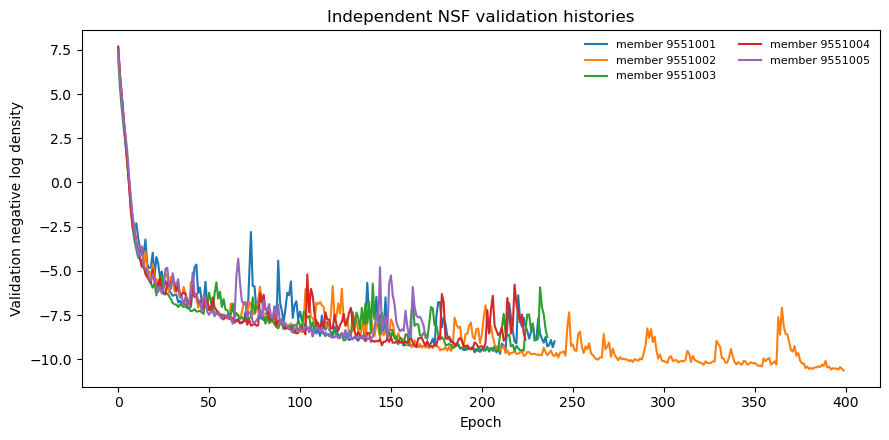

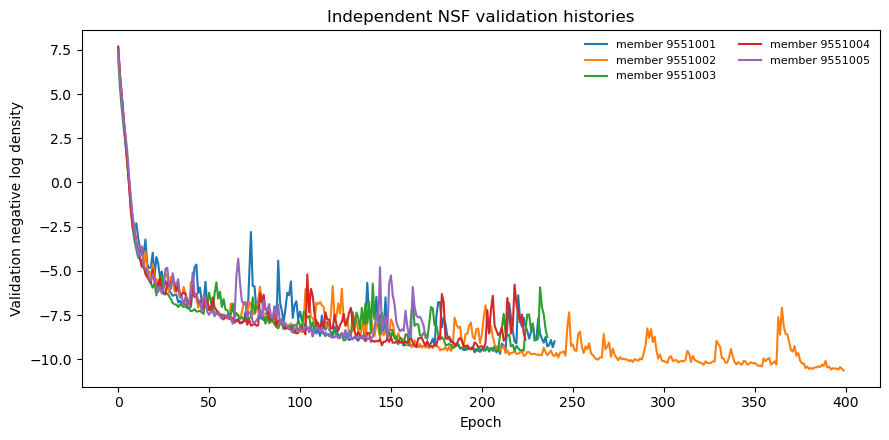

In [3]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 4.5))
for seed in manifest["member_seeds"]:
    history = pd.read_csv(root / f"member_{seed}" / "training_history.csv")
    ax.plot(history.epoch, history.validation_loss, label=f"member {seed}")
ax.set(xlabel="Epoch", ylabel="Validation negative log density", title="Independent NSF validation histories")
ax.legend(frameon=False, fontsize=8, ncol=2)
fig.tight_layout()
display(fig)

## Scope

A decreasing validation loss is an engineering result, not scientific
validation. Joint expected coverage, marginal SBC, L-C2ST, and new-simulation
PPC determine whether this posterior is usable.